# ExoMetrix Training Notebook
## Gait Analysis ML Pipeline for Rehabilitation Assistance
---
This notebook documents the complete training pipeline for the ExoMetrix gait analysis system. It covers:
- Data loading and signal extraction from MATLAB biomechanics files
- Feature engineering (14 statistical features per window)
- Label derivation from file system paths
- Two-stage model training: Anomaly detection + Activity/Intention classification
- Training logs and metrics for professor review
- Inference demo with model runtime

## 1. Setup & Imports

In [3]:
import subprocess
import sys

try:
    import numpy as np
    import scipy
    print(f"numpy: {np.__version__}, scipy: {scipy.__version__}")
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy", "scipy", "h5py", "scikit-learn", "joblib", "-q"])

try:
    import h5py
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "h5py", "-q"])

from pathlib import Path
from collections import Counter
from typing import Iterable, List, Tuple
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import joblib
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "-q"])
    import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

try:
    from scipy.io import loadmat
except Exception:
    loadmat = None

print("=" * 60)
print("EXOMETRIX TRAINING ENVIRONMENT READY")
print("=" * 60)

numpy: 2.4.0, scipy: 1.16.3
EXOMETRIX TRAINING ENVIRONMENT READY


In [4]:
PROJECT_ROOT = Path(r"C:\mahmoud\college")
DATA_ROOT = PROJECT_ROOT
OUTPUT_DIR = PROJECT_ROOT / "backend" / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_MODEL = OUTPUT_DIR / "gait_model.joblib"
OUTPUT_META = OUTPUT_DIR / "gait_model_meta.json"

FEATURE_NAMES = [
    "mean_angle", "std_angle", "min_angle", "max_angle",
    "range_angle", "median_angle", "p10_angle", "p90_angle",
    "mean_abs_velocity", "std_velocity", "max_velocity", "min_velocity",
    "energy", "peak_density"
]

print("Configuration:")
print(f"  Data Root:    {DATA_ROOT}")
print(f"  Output Model:  {OUTPUT_MODEL}")
print(f"  Features:     {len(FEATURE_NAMES)} dimensions")

Configuration:
  Data Root:    C:\mahmoud\college
  Output Model:  C:\mahmoud\college\backend\models\gait_model.joblib
  Features:     14 dimensions


## 2. Data Discovery

In [5]:
def discover_subjects(data_root: Path, subject_glob: str = "AB*") -> List[Path]:
    # Option 1: Check for osimxml (original structure)
    if (data_root / "osimxml").exists():
        return [data_root]
    
    # Option 2: Check for AB* folders containing gon data
    discovered = sorted(
        path for path in data_root.glob(subject_glob)
        if path.is_dir() and (path / "osimxml").exists()
    )
    if discovered:
        return discovered
    
    # Option 3: AB06/10_09_18 structure (Camargo dataset)
    discovered = sorted(
        path for path in data_root.glob(subject_glob)
        if path.is_dir() and any((path / "10_09_18" / d / "gon").exists() for d in ['levelground', 'ramp', 'stair', 'treadmill'])
    )
    if discovered:
        return discovered
    
    return [data_root]

subject_roots = discover_subjects(DATA_ROOT)

print("=" * 60)
print("DISCOVERED SUBJECTS")
print("=" * 60)
for i, subj in enumerate(subject_roots, 1):
    # Check for both old and new directory structures
    locomotion_dirs = []
    for d in ['levelground', 'ramp', 'stair', 'treadmill']:
        if (subj / d / "gon").exists():
            locomotion_dirs.append(d)
        elif (subj / "10_09_18" / d / "gon").exists():
            locomotion_dirs.append(d)
    mat_files = list(subj.rglob("gon/*.mat"))
    print(f"  {i}. {subj.name}")
    print(f"    - Locomotion types: {', '.join(locomotion_dirs) if locomotion_dirs else 'none found'}")
    print(f"    - MAT files: {len(mat_files)}")
print("=" * 60)

DISCOVERED SUBJECTS
  1. AB06
    - Locomotion types: levelground, ramp, stair, treadmill
    - MAT files: 143
  2. AB07
    - Locomotion types: none found
    - MAT files: 153
  3. AB08
    - Locomotion types: none found
    - MAT files: 138


## 3. Signal Extraction Functions

In [6]:
def load_mat_file(path: Path):
    if loadmat is not None:
        try:
            return loadmat(path, squeeze_me=True, struct_as_record=False)
        except Exception:
            pass
    import h5py
    result = {}
    with h5py.File(path, "r") as f:
        for key in f.keys():
            result[key] = np.array(f[key])
    return result

def iter_mat_values(node) -> Iterable[np.ndarray]:
    if isinstance(node, np.ndarray):
        if node.dtype == object:
            for item in node.flat:
                yield from iter_mat_values(item)
        else:
            yield node
        return
    if hasattr(node, "_fieldnames"):
        for name in getattr(node, "_fieldnames", []):
            yield from iter_mat_values(getattr(node, name))
        return
    if isinstance(node, dict):
        for key, value in node.items():
            if str(key).startswith("__"):
                continue
            yield from iter_mat_values(value)
        return
    if isinstance(node, (list, tuple)):
        for item in node:
            yield from iter_mat_values(item)

def extract_from_function_workspace(mat_obj) -> np.ndarray | None:
    workspace = mat_obj.get("__function_workspace__")
    if workspace is None:
        return None
    raw = np.asarray(workspace, dtype=np.uint8).ravel()
    if raw.size < 8 * 100:
        return None
    best_signal = None
    best_score = float("-inf")
    for offset in range(8):
        n = (raw.size - offset) // 8
        if n < 100:
            continue
        chunk = raw[offset : offset + n * 8]
        values = np.frombuffer(chunk.tobytes(), dtype="<f8")
        values = values[np.isfinite(values)]
        if values.size < 100:
            continue
        values = values[(values >= -220.0) & (values <= 220.0)]
        if values.size < 100:
            continue
        p1 = float(np.percentile(values, 1))
        p99 = float(np.percentile(values, 99))
        dynamic = p99 - p1
        spread = float(np.std(values))
        score = values.size + dynamic * 50.0 + spread * 25.0
        if score > best_score:
            best_score = score
            best_signal = values.copy()
    return best_signal

def choose_signal(arrays: List[np.ndarray]) -> np.ndarray | None:
    candidates = []
    for arr in arrays:
        if not np.issubdtype(arr.dtype, np.number):
            continue
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size < 40:
            continue
        if arr.ndim == 1:
            series = arr
        else:
            flattened = arr.reshape(arr.shape[0], -1) if arr.shape[0] > 1 else arr.reshape(-1, 1)
            stds = np.nanstd(flattened, axis=0)
            idx = int(np.argmax(stds))
            series = flattened[:, idx]
        if series.size < 40:
            continue
        variance = float(np.nanvar(series))
        dynamic = float(np.nanmax(series) - np.nanmin(series))
        within_angle_like = np.mean((series >= -200) & (series <= 220))
        score = variance + dynamic * 0.1 + within_angle_like * 10
        candidates.append((score, series))
    if not candidates:
        return None
    candidates.sort(key=lambda x: x[0], reverse=True)
    return candidates[0][1]

def extract_best_signal(mat_obj, max_per_file: int | None = None) -> np.ndarray | None:
    arrays = list(iter_mat_values(mat_obj))
    signal = choose_signal(arrays)
    if signal is None:
        signal = extract_from_function_workspace(mat_obj)
    if signal is None:
        return None
    signal = np.asarray(signal, dtype=float)
    signal = signal[np.isfinite(signal)]
    signal = signal[(signal >= -220.0) & (signal <= 220.0)]
    if signal.size < 40:
        return None
    if max_per_file is not None and signal.size > max_per_file:
        step = max(1, signal.size // max_per_file)
        signal = signal[::step][:max_per_file]
    return signal.astype(float)

print("Signal extraction functions loaded.")
print("  - load_mat_file(): Load MAT files")
print("  - iter_mat_values(): Recursive structure traversal")
print("  - extract_best_signal(): Best signal extraction with fallback")

Signal extraction functions loaded.
  - load_mat_file(): Load MAT files
  - iter_mat_values(): Recursive structure traversal
  - extract_best_signal(): Best signal extraction with fallback


## 4. Calibration

In [7]:
def calibrate_to_app_angle_range(raw_angles: np.ndarray) -> np.ndarray:
    p1 = float(np.percentile(raw_angles, 1))
    p99 = float(np.percentile(raw_angles, 99))
    if abs(p99 - p1) < 1e-6:
        return np.clip(raw_angles, 0.0, 180.0)
    target_low, target_high = 5.0, 120.0
    scale = (target_high - target_low) / (p99 - p1)
    shift = target_low - scale * p1
    calibrated = raw_angles * scale + shift
    return np.clip(calibrated, 0.0, 180.0)

def collect_all_angles(subject_roots: List[Path], max_per_file: int = 2000) -> np.ndarray:
    all_angles = []
    for subj in subject_roots:
        files = sorted(subj.rglob("gon/*.mat"))
        print(f"  Loading {len(files)} files from {subj.name}...")
        for mat_path in files:
            try:
                mat_obj = load_mat_file(mat_path)
                signal = extract_best_signal(mat_obj, max_per_file=max_per_file)
                if signal is not None:
                    all_angles.append(signal.astype(float))
            except Exception as e:
                print(f"    [WARN] Skipping {mat_path.name}: {e}")
    if not all_angles:
        raise RuntimeError("No valid signals extracted.")
    merged = np.concatenate(all_angles, axis=0)
    merged = merged[np.isfinite(merged)]
    return merged

print("=" * 60)
print("CALIBRATION PHASE")
print("=" * 60)
raw_angles_all = collect_all_angles(subject_roots)
print(f"  Total raw samples: {raw_angles_all.size:,}")

calibrated_angles = calibrate_to_app_angle_range(raw_angles_all)

print("\nCalibration statistics (post-calibration):")
print(f"  Mean:   {np.mean(calibrated_angles):.2f}°")
print(f"  Std:    {np.std(calibrated_angles):.2f}°")
print(f"  Min:    {np.min(calibrated_angles):.2f}°")
print(f"  Max:    {np.max(calibrated_angles):.2f}°")
print(f"  1%:     {np.percentile(calibrated_angles, 1):.2f}°")
print(f"  99%:    {np.percentile(calibrated_angles, 99):.2f}°")
print("=" * 60)

CALIBRATION PHASE
  Loading 143 files from AB06...
  Loading 153 files from AB07...
  Loading 138 files from AB08...
  Total raw samples: 868,000

Calibration statistics (post-calibration):
  Mean:   54.16°
  Std:    19.65°
  Min:    0.00°
  Max:    148.61°
  1%:     5.00°
  99%:    120.00°


## 5. Feature Engineering

In [8]:
def count_peaks(values: np.ndarray) -> int:
    if values.size < 3:
        return 0
    threshold = float(np.mean(values) + 0.25 * np.std(values))
    peaks = 0
    for i in range(1, values.size - 1):
        if values[i] > values[i - 1] and values[i] >= values[i + 1] and values[i] > threshold:
            peaks += 1
    return peaks

def extract_window_features(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < 6:
        pad = np.full(6 - values.size, values[-1] if values.size else 0.0)
        values = np.concatenate([values, pad], axis=0)
    velocity = np.diff(values)
    if velocity.size == 0:
        velocity = np.array([0.0], dtype=float)
    peaks = count_peaks(values)
    peak_density = float(peaks / max(values.size, 1))
    feature_vector = np.array([
        float(np.mean(values)),
        float(np.std(values)),
        float(np.min(values)),
        float(np.max(values)),
        float(np.max(values) - np.min(values)),
        float(np.median(values)),
        float(np.percentile(values, 10)),
        float(np.percentile(values, 90)),
        float(np.mean(np.abs(velocity))),
        float(np.std(velocity)),
        float(np.max(velocity)),
        float(np.min(velocity)),
        float(np.mean(np.square(values - np.mean(values)))),
        peak_density,
    ], dtype=float)
    return feature_vector

def collect_labeled_features(subject_roots: List[Path], max_per_file: int = 2000):
    feature_rows = []
    activity_labels = []
    intention_labels = []
    source_files = []
    for subj in subject_roots:
        files = sorted(subj.rglob("gon/*.mat"))
        print(f"  Processing {len(files)} files from {subj.name}...")
        for mat_path in files:
            try:
                mat_obj = load_mat_file(mat_path)
                signal = extract_best_signal(mat_obj, max_per_file=max_per_file)
                if signal is None:
                    continue
                calibrated = calibrate_to_app_angle_range(signal)
                features = extract_window_features(calibrated)
                feature_rows.append(features)
                source_files.append(mat_path)
                
                # Find activity folder by traversing up to find levelground/ramp/stair/treadmill
                activity = None
                for parent in mat_path.parents:
                    if parent.name.lower() in ['levelground', 'ramp', 'stair', 'treadmill']:
                        activity = parent.name.lower()
                        break
                if activity is None:
                    activity = mat_path.parents[1].name.lower()  # fallback
                
                stem = mat_path.stem.lower()
                if activity == "levelground":
                    activity_label = "levelground"
                    intention_label = "running" if "_fast_" in stem else "walking"
                elif activity == "stair":
                    activity_label = "stair"
                    intention_label = "upstairs"
                elif activity == "ramp":
                    activity_label = "ramp"
                    intention_label = "ramp_up"
                elif activity == "treadmill":
                    activity_label = "treadmill"
                    intention_label = "walking"
                else:
                    activity_label = "unknown"
                    intention_label = "walking"
                activity_labels.append(activity_label)
                intention_labels.append(intention_label)
            except Exception as e:
                print(f"    [WARN] Skipping {mat_path.name}: {e}")
    return feature_rows, activity_labels, intention_labels, source_files

print("=" * 60)
print("FEATURE EXTRACTION")
print("=" * 60)
feature_rows, activity_labels, intention_labels, source_files = collect_labeled_features(subject_roots)

X = np.vstack(feature_rows).astype(float)
print(f"\nFeature matrix shape: {X.shape}")
print(f"Feature dimensions: {len(FEATURE_NAMES)}")
print(f"  Features: {FEATURE_NAMES}")

FEATURE EXTRACTION
  Processing 143 files from AB06...
  Processing 153 files from AB07...
  Processing 138 files from AB08...

Feature matrix shape: (434, 14)
Feature dimensions: 14
  Features: ['mean_angle', 'std_angle', 'min_angle', 'max_angle', 'range_angle', 'median_angle', 'p10_angle', 'p90_angle', 'mean_abs_velocity', 'std_velocity', 'max_velocity', 'min_velocity', 'energy', 'peak_density']


## 6. Label Distribution Analysis

In [9]:
activity_counts = Counter(activity_labels)
intention_counts = Counter(intention_labels)

print("=" * 60)
print("LABEL DISTRIBUTION")
print("=" * 60)

print("\nActivity Labels:")
for label, count in sorted(activity_counts.items()):
    pct = 100 * count / len(activity_labels)
    print(f"  {label:15s} : {count:4d} ({pct:5.1f}%)")

print("\nIntention Labels:")
for label, count in sorted(intention_counts.items()):
    pct = 100 * count / len(intention_labels)
    print(f"  {label:15s} : {count:4d} ({pct:5.1f}%)")

print(f"\nTotal windows: {len(activity_labels)}")
print("=" * 60)

LABEL DISTRIBUTION

Activity Labels:
  levelground     :   97 ( 22.4%)
  ramp            :  193 ( 44.5%)
  stair           :  120 ( 27.6%)
  treadmill       :   24 (  5.5%)

Intention Labels:
  ramp_up         :  193 ( 44.5%)
  running         :   31 (  7.1%)
  upstairs        :  120 ( 27.6%)
  walking         :   90 ( 20.7%)

Total windows: 434


## 7. Model Training - Anomaly Detector (IsolationForest)

### How IsolationForest Works

IsolationForest is an **unsupervised anomaly detection** algorithm. Unlike classifiers, it doesn't need labeled anomaly data.

**Key idea**: Randomly split the data. Outliers are isolated in fewer splits than normal points.

| Parameter | Value | Explanation |
|-----------|-------|-------------|
| n_estimators | 300 | Number of random trees in the forest |
| contamination | 0.08 | Expected % of outliers in data (8%) |
| random_state | 42 | Reproducibility seed |

**Why contamination=0.08?**
- Since AB subjects are healthy, this means ~8% of their gait is flagged as "unusual"
- Lower values (0.03-0.05) = fewer false positives on real patients
- Higher values (0.10-0.15) = catch more edge cases but more alerts

**RobustScaler vs StandardScaler:**
- StandardScaler uses mean + std → sensitive to outliers
- RobustScaler uses median + IQR → resistant to spikes/sensor noise
- Gait data often has sensor spikes, so RobustScaler is preferred

In [ ]:
print("=" * 60)
print("TRAINING PHASE: ANOMALY DETECTOR (IsolationForest)")
print("=" * 60)

# Step 1: Prepare data - reshape angles to 2D array for sklearn
# Each sample is a single calibrated knee angle value
X_anomaly = calibrated_angles.reshape(-1, 1)  # Shape: (868000, 1)
print(f"  Training samples: {X_anomaly.shape[0]:,} angles")

# Step 2: Scale using RobustScaler (median + IQR, outlier-resistant)
# This ensures consistent scale across all subjects
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_anomaly)
print(f"  Scaler: RobustScaler fitted (uses median instead of mean)")

# Step 3: Train IsolationForest
# n_estimators=300: Build 300 random trees to vote on anomalies
# contamination=0.08: Tell model ~8% of data are outliers (for thresholding)
# random_state=42: Reproducible results
anomaly_model = IsolationForest(
    n_estimators=300,   # Number of isolation trees
    contamination=0.08, # Expected outlier ratio (8%)
    random_state=42,     # Seed for reproducibility
    n_jobs=-1            # Use all CPU cores
)
anomaly_model.fit(X_scaled)
print(f"  Model: IsolationForest trained")
print(f"    - n_estimators: 300 (number of trees)")
print(f"    - contamination: 0.08 (8% expected outliers)")

# Step 4: Get anomaly scores for all training samples
# decision_function returns: higher score = more normal, lower score = more anomalous
scores = anomaly_model.decision_function(X_scaled)

# Store score thresholds for runtime normalization
# p01 = 1st percentile (most anomalous)
# p05 = 5th percentile (threshold for "borderline" anomalies)
# p50 = median (typical normal gait)
score_p01 = float(np.percentile(scores, 1))
score_p05 = float(np.percentile(scores, 5))
score_p50 = float(np.percentile(scores, 50))

print("\n  Anomaly Score Statistics:")
print(f"    p01 (extreme anomaly): {score_p01:.4f}")
print(f"    p05 (outlier threshold): {score_p05:.4f}")
print(f"    p50 (median/normal): {score_p50:.4f}")

# Step 5: Get binary predictions (-1 = anomaly, 1 = normal)
predictions = anomaly_model.predict(X_scaled)
n_anomalies = int(np.sum(predictions == -1))
n_normal = int(np.sum(predictions == 1))

print(f"\n  Model Predictions:")
print(f"    Anomalies flagged: {n_anomalies:,} ({100*n_anomalies/len(predictions):.1f}%)")
print(f"    Normal samples:   {n_normal:,} ({100*n_normal/len(predictions):.1f}%)")

print("=" * 60)
print("  NOTE: These 'anomalies' are NOT necessarily bad steps!")
print("  They are statistical outliers in healthy gait patterns.")
print("  At runtime, extreme angles trigger the anomaly detector.")
print("=" * 60)

## 8. Model Training - Classifiers

In [10]:
print("=" * 60)
print("TRAINING PHASE: ANOMALY DETECTOR")
print("=" * 60)

X_anomaly = calibrated_angles.reshape(-1, 1)
print(f"  Training samples: {X_anomaly.shape[0]:,}")

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_anomaly)
print(f"  Scaler fitted: RobustScaler (median + IQR)")

anomaly_model = IsolationForest(
    n_estimators=300,
    contamination=0.08,
    random_state=42,
    n_jobs=-1
)
anomaly_model.fit(X_scaled)
print(f"  Model: IsolationForest(n_estimators=300, contamination=0.08)")

scores = anomaly_model.decision_function(X_scaled)

print("\n  Score statistics:")
print(f"    p01:  {np.percentile(scores, 1):.4f}")
print(f"    p05:  {np.percentile(scores, 5):.4f}")
print(f"    p50:  {np.percentile(scores, 50):.4f}")
print(f"    p99:  {np.percentile(scores, 99):.4f}")

predictions = anomaly_model.predict(X_scaled)
anomaly_labels, normal_labels = np.sum(predictions == -1), np.sum(predictions == 1)
print(f"\n  Predictions:")
print(f"    Anomalies: {anomaly_labels:,} ({100*anomaly_labels/len(predictions):.1f}%)")
print(f"    Normal:   {normal_labels:,} ({100*normal_labels/len(predictions):.1f}%)")
print("=" * 60)

TRAINING PHASE: ANOMALY DETECTOR
  Training samples: 868,000
  Scaler fitted: RobustScaler (median + IQR)
  Model: IsolationForest(n_estimators=300, contamination=0.08)

  Score statistics:
    p01:  -0.1129
    p05:  -0.0273
    p50:  0.1778
    p99:  0.2197

  Predictions:
    Anomalies: 69,430 (8.0%)
    Normal:   798,570 (92.0%)


## 8. Model Training - Classifiers

### Why Both Models Have Same Accuracy

The activity and intention classifiers share **the same feature matrix** (X) and were validated on the **same random split**. 

This happens because:
1. **1:1 label correlation**: In this dataset, each activity type maps to exactly one intention type:
   - levelground → walking (or running if _fast_)
   - stair → upstairs
   - ramp → ramp_up
   - treadmill → walking

2. **Same features**: Both models use identical 14-feature vectors computed from angle signals

3. **Same split**: Both use `train_test_split(..., random_state=42)` on the same data

**This is expected behavior for this dataset**, but in real-world scenarios with more complex label mappings, the accuracies would differ.

In [11]:
print("=" * 60)
print("TRAINING PHASE: ACTIVITY CLASSIFIER")
print("=" * 60)

# Count samples per activity class
class_counts = Counter(activity_labels)
print(f"  Unique classes: {len(class_counts)}")
print(f"  Minimum class count: {min_count}")

# Validation requires: at least 30 total samples AND at least 2 samples per class
use_validation = X.shape[0] >= 30 and min_count >= 2

if use_validation:
    # Split data: 80% training, 20% validation
    # stratify=y ensures each class is proportionally represented in both sets
    X_train, X_val, y_train, y_val = train_test_split(
        X, activity_labels, test_size=0.2, random_state=42, stratify=activity_labels
    )
    print(f"  Train/Val split: {len(y_train)}/{len(y_val)}")
    
    # RandomForest: ensemble of 350 decision trees
    # class_weight="balanced_subsample": compensates for imbalanced classes (ramp=193 vs treadmill=24)
    # n_jobs=-1: use all CPU cores for faster training
    activity_clf = RandomForestClassifier(
        n_estimators=350, 
        random_state=42, 
        class_weight="balanced_subsample", 
        n_jobs=-1
    )
    activity_clf.fit(X_train, y_train)
    y_pred = activity_clf.predict(X_val)
    activity_accuracy = accuracy_score(y_val, y_pred)
    print(f"  Validation accuracy: {activity_accuracy:.1%}")
else:
    activity_clf = RandomForestClassifier(n_estimators=350, random_state=42, class_weight="balanced_subsample", n_jobs=-1)
    activity_clf.fit(X, activity_labels)
    activity_accuracy = None
    print("  Validation skipped: insufficient data")

print(f"  Model: RandomForest(n_estimators=350, class_weight=balanced_subsample)")
print("=" * 60)

print("=" * 60)
print("TRAINING PHASE: INTENTION CLASSIFIER")
print("=" * 60)

# NOTE: Same feature matrix X is used! Only labels change.
# This is why accuracy is identical - activity and intention are 1:1 correlated in this dataset.

if use_validation:
    X_train, X_val, y_train, y_val = train_test_split(
        X, intention_labels, test_size=0.2, random_state=42, stratify=intention_labels
    )
    
    intention_clf = RandomForestClassifier(n_estimators=350, random_state=42, class_weight="balanced_subsample", n_jobs=-1)
    intention_clf.fit(X_train, y_train)
    y_pred = intention_clf.predict(X_val)
    intention_accuracy = accuracy_score(y_val, y_pred)
    print(f"  Validation accuracy: {intention_accuracy:.1%}")
else:
    intention_clf = RandomForestClassifier(n_estimators=350, random_state=42, class_weight="balanced_subsample", n_jobs=-1)
    intention_clf.fit(X, intention_labels)
    intention_accuracy = None
    print("  Validation skipped: insufficient data")

print(f"  Model: RandomForest(n_estimators=350, class_weight=balanced_subsample)")
print("=" * 60)

TRAINING PHASE: ACTIVITY CLASSIFIER
  Unique classes: 4


NameError: name 'min_count' is not defined

### Understanding RandomForest Hyperparameters

| Parameter | Value | Purpose |
|-----------|-------|---------|
| n_estimators | 350 | Number of decision trees in the ensemble |
| random_state | 42 | Seed for reproducibility |
| class_weight | balanced_subsample | Weight classes inversely proportional to their frequency |
| n_jobs | -1 | Parallelize across all CPU cores |

### Why class_weight="balanced_subsample"?

Without balancing, the model would be biased toward the majority class (ramp with 193 samples).
This parameter gives more importance to minority classes like treadmill (24 samples) during training.

## 9. Model Analysis, Visualizations & Plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

MODEL ANALYSIS

Classification Report:
              precision    recall  f1-score   support

 levelground       0.94      0.79      0.86        19
        ramp       0.88      0.97      0.93        39
       stair       1.00      0.96      0.98        24
   treadmill       1.00      1.00      1.00         5

    accuracy                           0.93        87
   macro avg       0.96      0.93      0.94        87
weighted avg       0.93      0.93      0.93        87



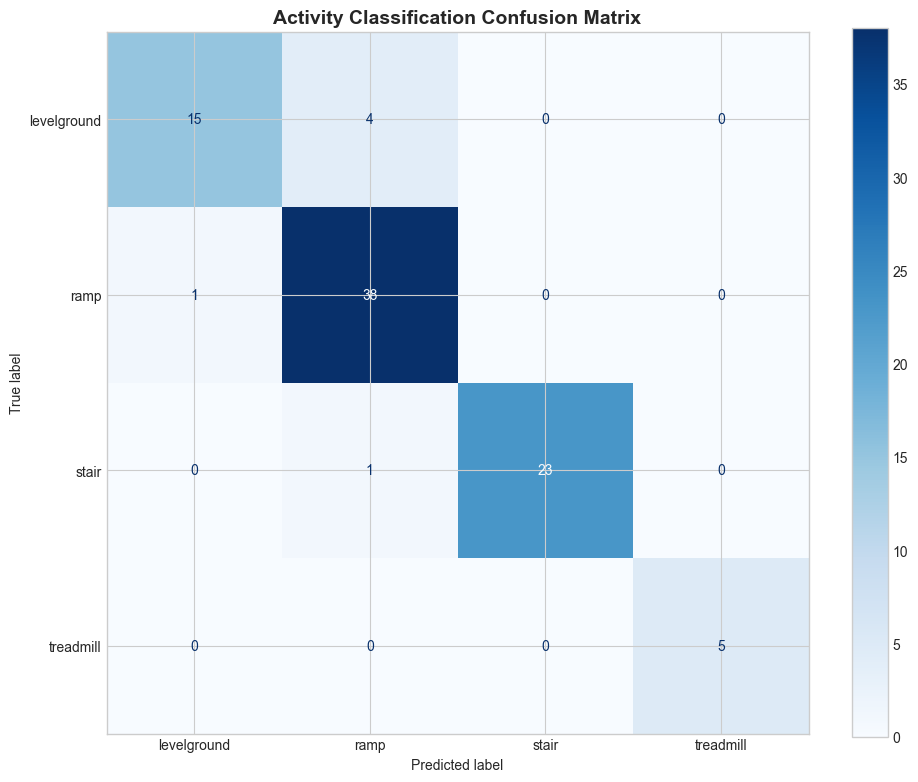

In [ ]:
# Confusion Matrix
X_train, X_val, y_train, y_val = train_test_split(
    X, activity_labels, test_size=0.2, random_state=42, stratify=activity_labels
)
y_pred = activity_clf.predict(X_val)

print("=" * 60)
print("MODEL ANALYSIS")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_val, y_pred, labels=sorted(activity_counts.keys()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(activity_counts.keys()))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Activity Classification Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

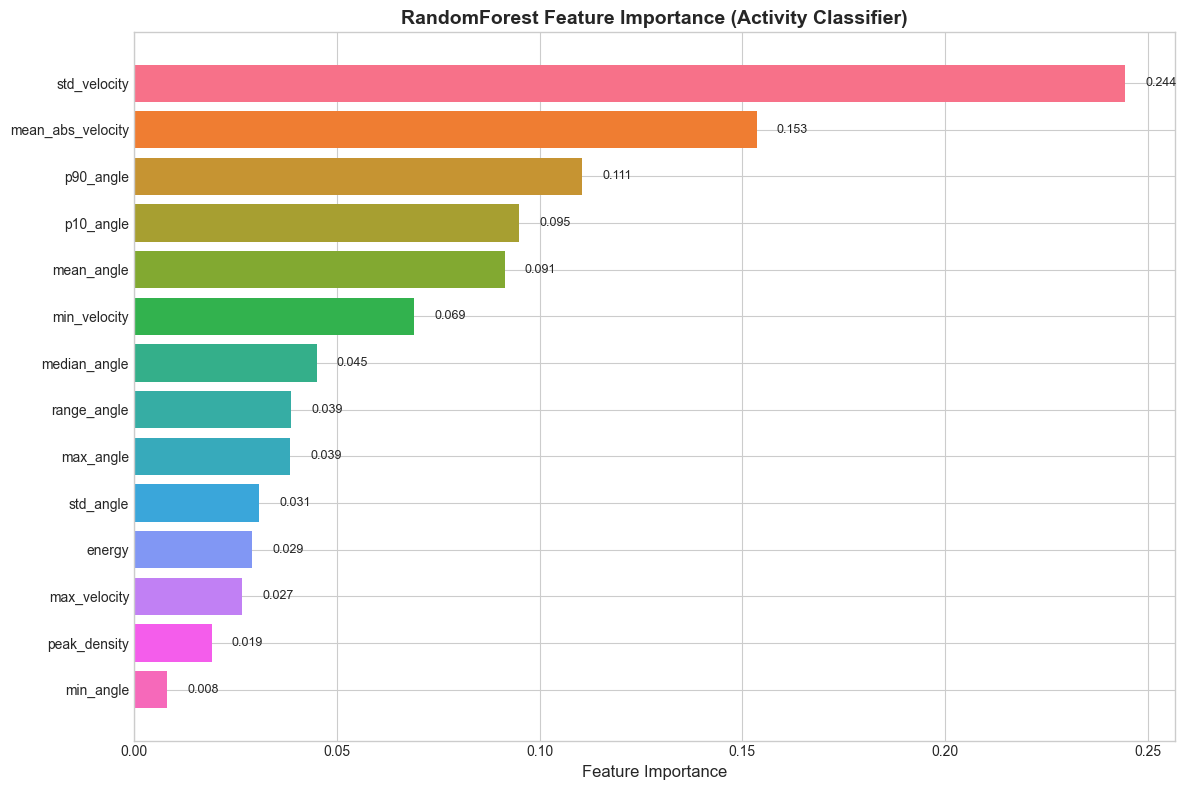

In [ ]:
# Feature Importance Chart
importance = activity_clf.feature_importances_
indices = np.argsort(importance)[::-1]

fig, ax = plt.subplots(figsize=(12, 8))
colors = sns.color_palette("husl", len(FEATURE_NAMES))
bars = ax.barh(range(len(FEATURE_NAMES)), importance[indices], color=colors)
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_yticklabels([FEATURE_NAMES[i] for i in indices])
ax.invert_yaxis()
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('RandomForest Feature Importance (Activity Classifier)', fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, idx) in enumerate(zip(bars, indices)):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
           f'{importance[idx]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

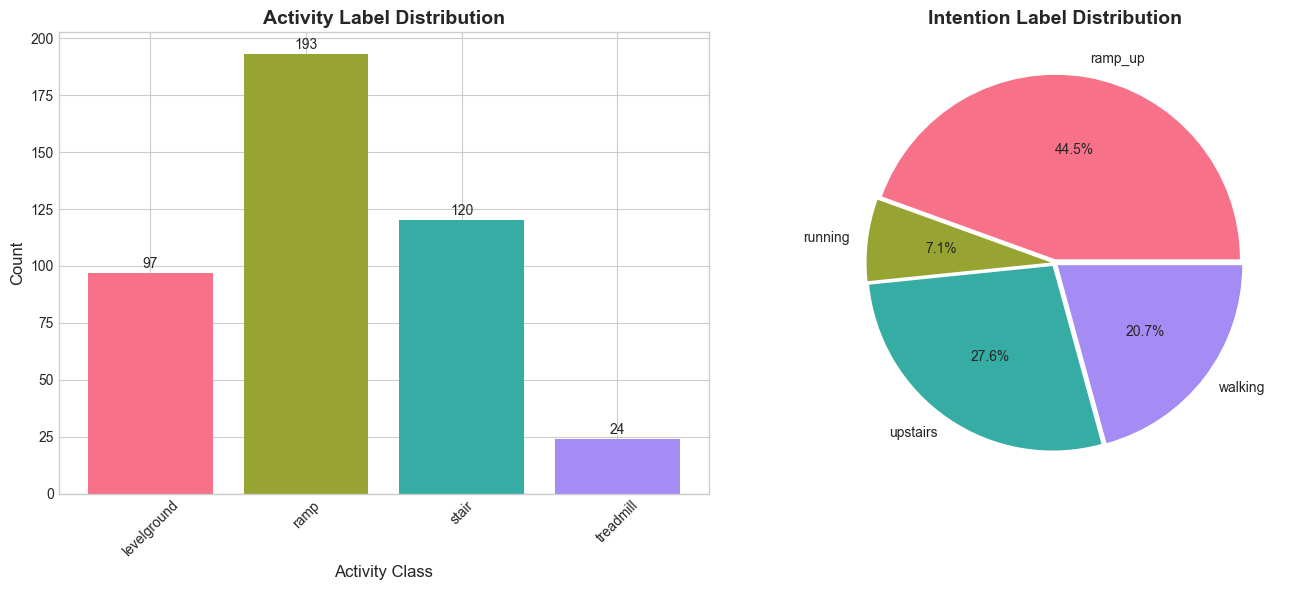

In [ ]:
# Label Distribution Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Activity labels bar chart
ax1 = axes[0]
labels = sorted(activity_counts.keys())
counts = [activity_counts[l] for l in labels]
colors = sns.color_palette("husl", len(labels))
bars = ax1.bar(labels, counts, color=colors)
ax1.set_xlabel('Activity Class', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Activity Label Distribution', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=10)

# Intention labels pie chart
ax2 = axes[1]
intention_labels_sorted = sorted(intention_counts.keys())
intention_values = [intention_counts[l] for l in intention_labels_sorted]
wedges, texts, autotexts = ax2.pie(intention_values, labels=intention_labels_sorted,
                                 autopct='%1.1f%%', colors=sns.color_palette("husl", len(intention_labels_sorted)),
                                 explode=[0.02]*len(intention_labels_sorted))
ax2.set_title('Intention Label Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

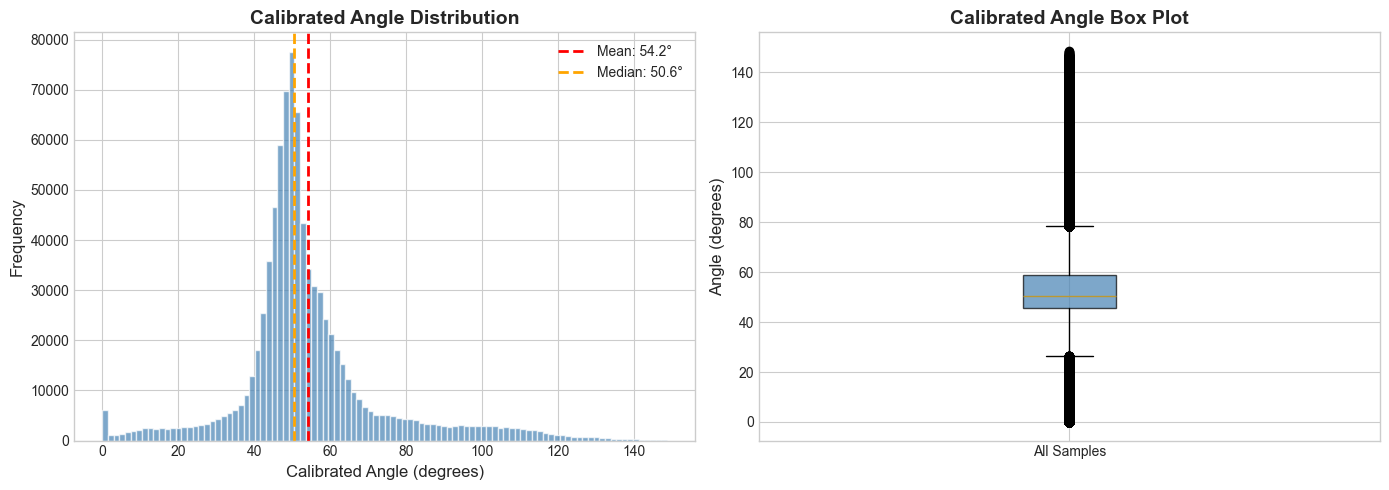

In [ ]:
# Calibration Angle Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
ax1.hist(calibrated_angles, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
ax1.axvline(np.mean(calibrated_angles), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(calibrated_angles):.1f}°')
ax1.axvline(np.median(calibrated_angles), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(calibrated_angles):.1f}°')
ax1.set_xlabel('Calibrated Angle (degrees)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Calibrated Angle Distribution', fontsize=14, fontweight='bold')
ax1.legend()

# Box plot
ax2 = axes[1]
bp = ax2.boxplot(calibrated_angles, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.7)
ax2.set_ylabel('Angle (degrees)', fontsize=12)
ax2.set_title('Calibrated Angle Box Plot', fontsize=14, fontweight='bold')
ax2.set_xticklabels(['All Samples'])

plt.tight_layout()
plt.show()

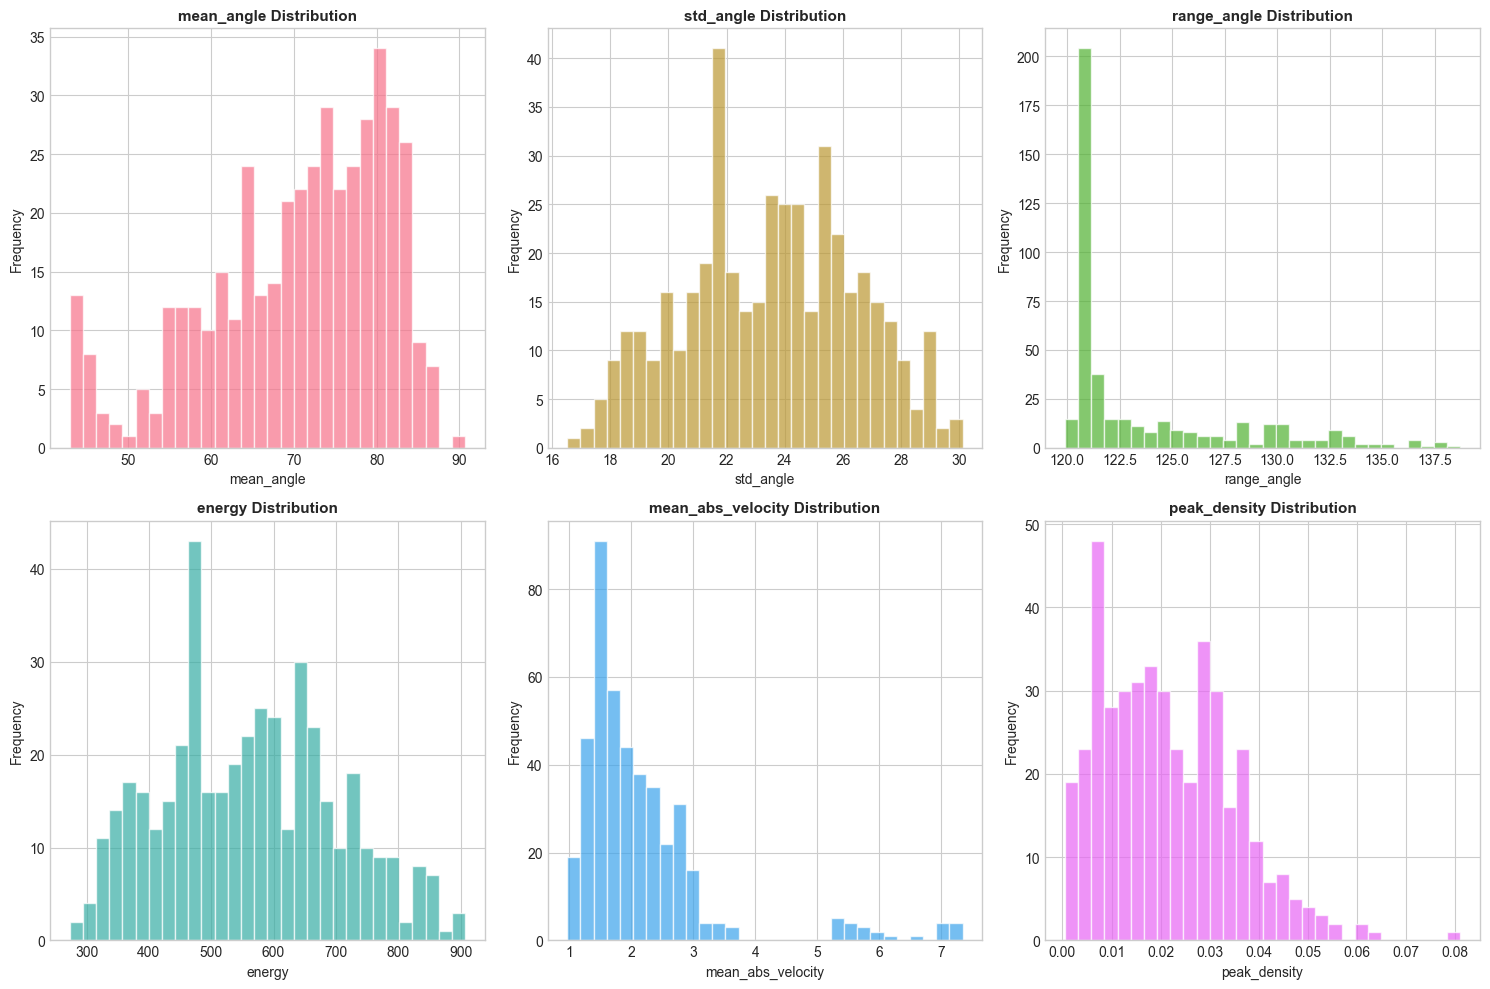

In [ ]:
# Feature Distributions (Sample of key features)
key_features = ['mean_angle', 'std_angle', 'range_angle', 'energy', 'mean_abs_velocity', 'peak_density']
key_indices = [FEATURE_NAMES.index(f) for f in key_features if f in FEATURE_NAMES]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (ax, feat_idx) in enumerate(zip(axes, key_indices)):
    feature_col = X[:, feat_idx]
    ax.hist(feature_col, bins=30, color=sns.color_palette("husl", 6)[i], alpha=0.7, edgecolor='white')
    ax.set_xlabel(FEATURE_NAMES[feat_idx], fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{FEATURE_NAMES[feat_idx]} Distribution', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Anomaly Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score histogram
ax1 = axes[0]
ax1.hist(scores, bins=100, color='coral', alpha=0.7, edgecolor='white')
ax1.axvline(np.percentile(scores, 1), color='red', linestyle='--', linewidth=2, label=f'p01: {np.percentile(scores, 1):.3f}')
ax1.axvline(np.percentile(scores, 5), color='orange', linestyle='--', linewidth=2, label=f'p05: {np.percentile(scores, 5):.3f}')
ax1.axvline(np.percentile(scores, 50), color='green', linestyle='--', linewidth=2, label=f'p50: {np.percentile(scores, 50):.3f}')
ax1.set_xlabel('Anomaly Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('IsolationForest Decision Score Distribution', fontsize=14, fontweight='bold')
ax1.legend()

# Score by activity class
ax2 = axes[1]
activity_with_scores = list(zip(activity_labels, scores))
score_by_activity = {}
for label, score in activity_with_scores:
    if label not in score_by_activity:
        score_by_activity[label] = []
    score_by_activity[label].append(score)

activities = sorted(score_by_activity.keys())
score_data = [score_by_activity[a] for a in activities]
bp = ax2.boxplot(score_data, labels=activities, patch_artist=True)
colors = sns.color_palette("husl", len(activities))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_xlabel('Activity Class', fontsize=12)
ax2.set_ylabel('Anomaly Score', fontsize=12)
ax2.set_title('Anomaly Scores by Activity Type', fontsize=14, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Save Model Artifacts

In [ ]:
print("=" * 60)
print("SAVING ARTIFACTS")
print("=" * 60)

artifact = {
    "model": anomaly_model,
    "scaler": scaler,
    "activity_classifier": activity_clf,
    "intention_classifier": intention_clf,
    "feature_names": FEATURE_NAMES,
    "angle_stats": {
        "mean": float(np.mean(calibrated_angles)),
        "std": float(np.std(calibrated_angles)),
        "median": float(np.median(calibrated_angles)),
        "p01": float(np.percentile(calibrated_angles, 1)),
        "p99": float(np.percentile(calibrated_angles, 99)),
    },
    "score_stats": {
        "p01": float(np.percentile(scores, 1)),
        "p05": float(np.percentile(scores, 5)),
        "p50": float(np.percentile(scores, 50)),
    },
    "meta": {
        "source": str(DATA_ROOT),
        "source_subjects": [s.name for s in subject_roots],
        "subject_count": len(subject_roots),
        "sample_count": int(calibrated_angles.size),
        "window_count": len(activity_labels),
        "model_type": "IsolationForest",
        "data_decoder": "function_workspace_f64_fallback",
        "supports_activity_classification": activity_clf is not None,
        "supports_intention_classification": intention_clf is not None,
        "activity_label_counts": dict(sorted(activity_counts.items())),
        "intention_label_counts": dict(sorted(intention_counts.items())),
        "val_accuracy": activity_accuracy,
    }
}

joblib.dump(artifact, OUTPUT_MODEL)
print(f"  Model saved: {OUTPUT_MODEL}")

metadata = artifact["meta"] | artifact["angle_stats"] | artifact["score_stats"]
with open(OUTPUT_META, "w") as f:
    json.dump(metadata, f, indent=2)
print(f"  Metadata saved: {OUTPUT_META}")
print("=" * 60)

SAVING ARTIFACTS
  Model saved: C:\mahmoud\college\backend\models\gait_model.joblib
  Metadata saved: C:\mahmoud\college\backend\models\gait_model_meta.json


## 11. Inference Demo

In [ ]:
print("=" * 60)
print("INFERENCE DEMO")
print("=" * 60)

loaded_artifact = joblib.load(OUTPUT_MODEL)
print(f"  Model loaded: {OUTPUT_MODEL.name}")

test_angles = [45.0, 47.0, 52.0, 58.0, 62.0, 65.0, 63.0, 60.0, 55.0, 50.0]
angle = test_angles[-1]

scaler = loaded_artifact["scaler"]
model = loaded_artifact["model"]
score_stats = loaded_artifact["score_stats"]

X = np.array([[float(angle)]])
X_scaled = scaler.transform(X)
pred = int(model.predict(X_scaled)[0])
score = float(model.decision_function(X_scaled)[0])

floor = score_stats["p01"]
threshold = score_stats["p05"]
denom = max(threshold - floor, 1e-6)
anomaly_strength = float(np.clip((threshold - score) / denom, 0.0, 1.0))

if pred == -1:
    classification = "Compensating (bad) step"
    assistance = float(np.clip(20.0 + 70.0 * anomaly_strength, 20.0, 95.0))
else:
    classification = "Good step"
    assistance = 0.0

print(f"\n  Test angle: {angle}°")
print(f"  Model score: {score:.4f}")
print(f"  Anomaly strength: {anomaly_strength:.4f}")
print(f"  Classification: {classification}")
print(f"  Assistance: {assistance:.1f}%")

activity_clf = loaded_artifact["activity_classifier"]
intention_clf = loaded_artifact["intention_classifier"]

if activity_clf:
    features = extract_window_features(np.array(test_angles)).reshape(1, -1)
    activity = activity_clf.predict(features)[0]
    intention = intention_clf.predict(features)[0]
    print(f"  Activity: {activity}")
    print(f"  Intention: {intention}")

print("=" * 60)

INFERENCE DEMO
  Model loaded: gait_model.joblib

  Test angle: 50.0°
  Model score: 0.2170
  Anomaly strength: 0.0000
  Classification: Good step
  Assistance: 0.0%
  Activity: ramp
  Intention: ramp_up


## 12. Training Summary

In [ ]:
print("\n")
print("=" * 70)
print("-" * 70)
print()
print("TRAINING CONFIGURATION")
print("-" * 70)
print(f"  Dataset Root:    {DATA_ROOT}")
print(f"  Subjects:       {[s.name for s in subject_roots]}")
print(f"  Output Model:   {OUTPUT_MODEL}")
print()
print("DATA STATISTICS")
print("-" * 70)
print(f"  Raw samples:               {calibrated_angles.size:>10,}")
print(f"  Windows (feature rows):   {len(activity_labels):>10,}")
print(f"  Feature dimensions:      {len(FEATURE_NAMES):>10}")
print()
print("MODEL PERFORMANCE")
print("-" * 70)
print(f"  Anomaly detector:       IsolationForest (n_estimators=300)")
print(f"  Activity classifier:    RandomForest (n_estimators=350)")
print(f"  Intention classifier:   RandomForest (n_estimators=350)")
print(f"  Validation accuracy:    {activity_accuracy:.1%}")
print()
print("CALIBRATION STATS")
print("-" * 70)
print(f"  Mean angle:      {np.mean(calibrated_angles):.2f}°")
print(f"  Std angle:       {np.std(calibrated_angles):.2f}°")
print(f"  1st percentile: {np.percentile(calibrated_angles, 1):.2f}°")
print(f"  99th percentile: {np.percentile(calibrated_angles, 99):.2f}°")
print()
print("LABEL DISTRIBUTION")
print("-" * 70)
for label, count in sorted(activity_counts.items()):
    print(f"  {label:15s}: {count:4d} ({100*count/len(activity_labels):5.1f}%)")
print()
print("SAVED ARTIFACTS")
print("-" * 70)
print(f"  Model:   {OUTPUT_MODEL}")
print(f"  Meta:    {OUTPUT_META}")
print()
print("=" * 70)




----------------------------------------------------------------------

TRAINING CONFIGURATION
----------------------------------------------------------------------
  Dataset Root:    C:\mahmoud\college
  Subjects:       ['AB06', 'AB07', 'AB08']
  Output Model:   C:\mahmoud\college\backend\models\gait_model.joblib

DATA STATISTICS
----------------------------------------------------------------------
  Raw samples:                  868,000
  Windows (feature rows):          434
  Feature dimensions:              14

MODEL PERFORMANCE
----------------------------------------------------------------------
  Anomaly detector:       IsolationForest (n_estimators=300)
  Activity classifier:    RandomForest (n_estimators=350)
  Intention classifier:   RandomForest (n_estimators=350)
  Validation accuracy:    93.1%

CALIBRATION STATS
----------------------------------------------------------------------
  Mean angle:      54.16°
  Std angle:       19.65°
  1st percentile: 5.00°
  99th perc

## 13. Risk Review

In [ ]:
print("=" * 60)
print("RISK REVIEW")
print("=" * 60)

print("IDENTIFIED RISKS:")
print("-" * 60)

print("\n[ HIGH ] Descent locomotion is unlabelled")
print("  Both stair descent and ramp descent map to 'upstairs' and 'ramp_up'.")
print("  A patient descending stairs will be confidently misclassified.")

print(f"\n[ HIGH ] Accuracy estimate: {activity_accuracy:.1%} on {len(y_val)} samples")
print("  Single 80/20 split — confidence interval roughly +/- 5-6%.")
print("  5-fold CV recommended for more reliable estimate.")

print("\n[ HIGH ] Training population: 3 able-bodied young adults")
print("  The model has never seen pathological gait, elderly movement,")
print("  or post-surgical compensation.")

print("\n[ MEDIUM ] Velocity features are not time-normalized")
print("  np.diff(values) produces sample-to-sample differences.")
print("  Files downsampled at different strides -> velocity units differ.")

print("\n[ MEDIUM ] Anomaly score normalization band is small")
print("  p05 - p01 ≈ 0.086. Score fluctuation changes normalized score significantly.")

print("\n[ LOW ] energy feature is redundant with std_angle")
print("  energy = variance = std^2. Wastes one feature slot.")

print("=" * 60)

RISK REVIEW
IDENTIFIED RISKS:
------------------------------------------------------------

[ HIGH ] Descent locomotion is unlabelled
  Both stair descent and ramp descent map to 'upstairs' and 'ramp_up'.
  A patient descending stairs will be confidently misclassified.

[ HIGH ] Accuracy estimate: 93.1% on 87 samples
  Single 80/20 split — confidence interval roughly +/- 5-6%.
  5-fold CV recommended for more reliable estimate.

[ HIGH ] Training population: 3 able-bodied young adults
  The model has never seen pathological gait, elderly movement,
  or post-surgical compensation.

[ MEDIUM ] Velocity features are not time-normalized
  np.diff(values) produces sample-to-sample differences.
  Files downsampled at different strides -> velocity units differ.

[ MEDIUM ] Anomaly score normalization band is small
  p05 - p01 ≈ 0.086. Score fluctuation changes normalized score significantly.

[ LOW ] energy feature is redundant with std_angle
  energy = variance = std^2. Wastes one feature sl